In [1]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, precision_score,
                             recall_score, average_precision_score)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import pickle
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Cell 2: Load Processed Data
print("=" * 50)
print("LOADING PROCESSED DATA")
print("=" * 50)

X_train = pd.read_csv('../../data/processed/X_train.csv')
y_train = pd.read_csv('../../data/processed/y_train.csv').squeeze()

X_val = pd.read_csv('../../data/processed/X_val.csv')
y_val = pd.read_csv('../../data/processed/y_val.csv').squeeze()

X_test = pd.read_csv('../../data/processed/X_test.csv')
y_test = pd.read_csv('../../data/processed/y_test.csv').squeeze()

print(f"X_train: {X_train.shape} | Fraud: {y_train.sum()}")
print(f"X_val:   {X_val.shape} | Fraud: {y_val.sum()}")
print(f"X_test:  {X_test.shape} | Fraud: {y_test.sum()}")

print("\n✅ All datasets loaded successfully!")

LOADING PROCESSED DATA
X_train: (396540, 37) | Fraud: 198270
X_val:   (42566, 37) | Fraud: 71
X_test:  (42559, 37) | Fraud: 71

✅ All datasets loaded successfully!


In [3]:
# Cell 3: Helper Function for Model Evaluation
def evaluate_model(model_name, y_true, y_pred, y_prob):
    print(f"\n{'='*50}")
    print(f"MODEL: {model_name}")
    print(f"{'='*50}")
    
    # Core metrics
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    
    print(f"Precision:  {precision:.4f}  (of all flagged fraud, how many were real?)")
    print(f"Recall:     {recall:.4f}  (of all real fraud, how many did we catch?)")
    print(f"F1-Score:   {f1:.4f}  (balance of precision & recall)")
    print(f"ROC-AUC:    {roc_auc:.4f}  (overall discrimination ability)")
    print(f"PR-AUC:     {pr_auc:.4f}  (performance on imbalanced data)")
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    print(f"\nConfusion Matrix:")
    print(f"  True Negative  (Legit correctly identified): {cm[0][0]:,}")
    print(f"  False Positive (Legit flagged as fraud):     {cm[0][1]:,}")
    print(f"  False Negative (Fraud missed):               {cm[1][0]:,}")
    print(f"  True Positive  (Fraud correctly caught):     {cm[1][1]:,}")
    
    return {
        'model': model_name,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc
    }

print("✅ Evaluation function ready!")

✅ Evaluation function ready!


In [4]:
# Cell 4: Logistic Regression - Baseline Model
print("=" * 50)
print("MODEL 1: LOGISTIC REGRESSION (Baseline)")
print("=" * 50)
print("Training... (this may take 1-2 minutes)")

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)

lr_model.fit(X_train, y_train)

# Predictions on validation set
lr_pred = lr_model.predict(X_val)
lr_prob = lr_model.predict_proba(X_val)[:, 1]

# Evaluate
lr_results = evaluate_model("Logistic Regression", y_val, lr_pred, lr_prob)

# Save model
with open('../../models/saved_models/logistic_regression.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

print("\n✅ Logistic Regression trained and saved!")

MODEL 1: LOGISTIC REGRESSION (Baseline)
Training... (this may take 1-2 minutes)

MODEL: Logistic Regression
Precision:  0.0632  (of all flagged fraud, how many were real?)
Recall:     0.9155  (of all real fraud, how many did we catch?)
F1-Score:   0.1182  (balance of precision & recall)
ROC-AUC:    0.9775  (overall discrimination ability)
PR-AUC:     0.6809  (performance on imbalanced data)

Confusion Matrix:
  True Negative  (Legit correctly identified): 41,531
  False Positive (Legit flagged as fraud):     964
  False Negative (Fraud missed):               6
  True Positive  (Fraud correctly caught):     65

✅ Logistic Regression trained and saved!


In [5]:
# Cell 5: Random Forest
print("=" * 50)
print("MODEL 2: RANDOM FOREST")
print("=" * 50)
print("Training... (this may take 2-3 minutes)")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions on validation set
rf_pred = rf_model.predict(X_val)
rf_prob = rf_model.predict_proba(X_val)[:, 1]

# Evaluate
rf_results = evaluate_model("Random Forest", y_val, rf_pred, rf_prob)

# Save model
with open('../../models/saved_models/random_forest.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

print("\n✅ Random Forest trained and saved!")

MODEL 2: RANDOM FOREST
Training... (this may take 2-3 minutes)

MODEL: Random Forest
Precision:  0.5660  (of all flagged fraud, how many were real?)
Recall:     0.8451  (of all real fraud, how many did we catch?)
F1-Score:   0.6780  (balance of precision & recall)
ROC-AUC:    0.9845  (overall discrimination ability)
PR-AUC:     0.8191  (performance on imbalanced data)

Confusion Matrix:
  True Negative  (Legit correctly identified): 42,449
  False Positive (Legit flagged as fraud):     46
  False Negative (Fraud missed):               11
  True Positive  (Fraud correctly caught):     60

✅ Random Forest trained and saved!


In [6]:
# Cell 6: XGBoost
print("=" * 50)
print("MODEL 3: XGBOOST")
print("=" * 50)
print("Training... (this may take 2-3 minutes)")

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='aucpr',
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# Predictions on validation set
xgb_pred = xgb_model.predict(X_val)
xgb_prob = xgb_model.predict_proba(X_val)[:, 1]

# Evaluate
xgb_results = evaluate_model("XGBoost", y_val, xgb_pred, xgb_prob)

# Save model
with open('../../models/saved_models/xgboost.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

print("\n✅ XGBoost trained and saved!")

MODEL 3: XGBOOST
Training... (this may take 2-3 minutes)

MODEL: XGBoost
Precision:  0.5175  (of all flagged fraud, how many were real?)
Recall:     0.8310  (of all real fraud, how many did we catch?)
F1-Score:   0.6378  (balance of precision & recall)
ROC-AUC:    0.9817  (overall discrimination ability)
PR-AUC:     0.8395  (performance on imbalanced data)

Confusion Matrix:
  True Negative  (Legit correctly identified): 42,440
  False Positive (Legit flagged as fraud):     55
  False Negative (Fraud missed):               12
  True Positive  (Fraud correctly caught):     59

✅ XGBoost trained and saved!


In [7]:
# Cell 7: LightGBM
print("=" * 50)
print("MODEL 4: LIGHTGBM")
print("=" * 50)
print("Training... (this may take 1-2 minutes)")

lgbm_model = LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1,
    verbose=-1
)

lgbm_model.fit(X_train, y_train)

# Predictions on validation set
lgbm_pred = lgbm_model.predict(X_val)
lgbm_prob = lgbm_model.predict_proba(X_val)[:, 1]

# Evaluate
lgbm_results = evaluate_model("LightGBM", y_val, lgbm_pred, lgbm_prob)

# Save model
with open('../../models/saved_models/lightgbm.pkl', 'wb') as f:
    pickle.dump(lgbm_model, f)

print("\n✅ LightGBM trained and saved!")

MODEL 4: LIGHTGBM
Training... (this may take 1-2 minutes)

MODEL: LightGBM
Precision:  0.4839  (of all flagged fraud, how many were real?)
Recall:     0.8451  (of all real fraud, how many did we catch?)
F1-Score:   0.6154  (balance of precision & recall)
ROC-AUC:    0.9833  (overall discrimination ability)
PR-AUC:     0.8453  (performance on imbalanced data)

Confusion Matrix:
  True Negative  (Legit correctly identified): 42,431
  False Positive (Legit flagged as fraud):     64
  False Negative (Fraud missed):               11
  True Positive  (Fraud correctly caught):     60

✅ LightGBM trained and saved!


ALL MODELS COMPARISON
                     precision    recall        f1   roc_auc    pr_auc
model                                                                 
Logistic Regression   0.063168  0.915493  0.118182  0.977522  0.680905
Random Forest         0.566038  0.845070  0.677966  0.984522  0.819064
XGBoost               0.517544  0.830986  0.637838  0.981729  0.839536
LightGBM              0.483871  0.845070  0.615385  0.983311  0.845322

RANKING BY F1 SCORE:
1. Random Forest             F1=0.6780 | Precision=0.5660 | Recall=0.8451 | PR-AUC=0.8191
2. XGBoost                   F1=0.6378 | Precision=0.5175 | Recall=0.8310 | PR-AUC=0.8395
3. LightGBM                  F1=0.6154 | Precision=0.4839 | Recall=0.8451 | PR-AUC=0.8453
4. Logistic Regression       F1=0.1182 | Precision=0.0632 | Recall=0.9155 | PR-AUC=0.6809

RANKING BY PR-AUC (Best for Imbalanced Data):
1. LightGBM                  PR-AUC=0.8453 | F1=0.6154
2. XGBoost                   PR-AUC=0.8395 | F1=0.6378
3. Random For

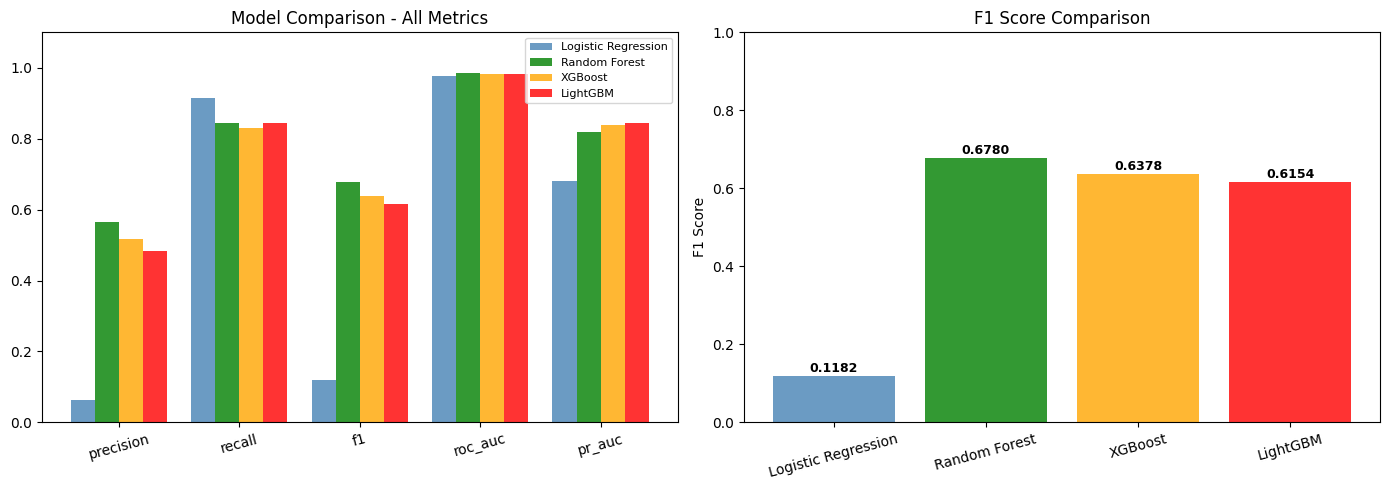


✅ Comparison plot saved!


In [8]:
# Cell 8: Model Comparison
print("=" * 60)
print("ALL MODELS COMPARISON")
print("=" * 60)

results = [lr_results, rf_results, xgb_results, lgbm_results]
results_df = pd.DataFrame(results)
results_df = results_df.set_index('model')

print(results_df.to_string())

print("\n" + "=" * 60)
print("RANKING BY F1 SCORE:")
print("=" * 60)
ranked = results_df.sort_values('f1', ascending=False)
for i, (model, row) in enumerate(ranked.iterrows(), 1):
    print(f"{i}. {model:<25} F1={row['f1']:.4f} | "
          f"Precision={row['precision']:.4f} | "
          f"Recall={row['recall']:.4f} | "
          f"PR-AUC={row['pr_auc']:.4f}")

print("\n" + "=" * 60)
print("RANKING BY PR-AUC (Best for Imbalanced Data):")
print("=" * 60)
ranked_prauc = results_df.sort_values('pr_auc', ascending=False)
for i, (model, row) in enumerate(ranked_prauc.iterrows(), 1):
    print(f"{i}. {model:<25} PR-AUC={row['pr_auc']:.4f} | "
          f"F1={row['f1']:.4f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
x = np.arange(len(metrics))
width = 0.2

colors = ['steelblue', 'green', 'orange', 'red']
for i, (model, row) in enumerate(results_df.iterrows()):
    axes[0].bar(x + i*width, row[metrics], width, 
                label=model, color=colors[i], alpha=0.8)

axes[0].set_title('Model Comparison - All Metrics')
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(metrics, rotation=15)
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1.1)

# F1 comparison bar
axes[1].bar(results_df.index, results_df['f1'], 
            color=colors, alpha=0.8)
axes[1].set_title('F1 Score Comparison')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1)
for i, (model, row) in enumerate(results_df.iterrows()):
    axes[1].text(i, row['f1'] + 0.01, f"{row['f1']:.4f}", 
                ha='center', fontweight='bold', fontsize=9)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../../docs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Comparison plot saved!")

In [10]:
# Cell 9: Hyperparameter Tuning - Random Forest (FAST VERSION)
from sklearn.model_selection import RandomizedSearchCV

print("=" * 50)
print("HYPERPARAMETER TUNING - RANDOM FOREST (FAST)")
print("=" * 50)
print("Training... (should take 3-5 minutes)")

# Sample only 20% of training data for tuning
from sklearn.utils import resample
X_train_sample, y_train_sample = resample(
    X_train, y_train,
    n_samples=int(len(X_train)*0.2),
    random_state=42
)
print(f"Using {len(X_train_sample):,} samples for tuning (20% sample)")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [8, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf_tuned = RandomizedSearchCV(
    RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),
    param_distributions=param_grid,
    n_iter=10,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_tuned.fit(X_train_sample, y_train_sample)

print(f"\nBest Parameters:")
for param, value in rf_tuned.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV F1 Score: {rf_tuned.best_score_:.4f}")

# Evaluate on validation set
rf_tuned_pred = rf_tuned.predict(X_val)
rf_tuned_prob = rf_tuned.predict_proba(X_val)[:, 1]
rf_tuned_results = evaluate_model("Random Forest (Tuned)",
                                   y_val, rf_tuned_pred, rf_tuned_prob)

# Save tuned model
with open('../../models/saved_models/random_forest_tuned.pkl', 'wb') as f:
    pickle.dump(rf_tuned, f)

print("\n✅ Tuned Random Forest saved!")

HYPERPARAMETER TUNING - RANDOM FOREST (FAST)
Training... (should take 3-5 minutes)
Using 79,308 samples for tuning (20% sample)
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Parameters:
  n_estimators: 100
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: log2
  max_depth: 15

Best CV F1 Score: 0.9990

MODEL: Random Forest (Tuned)
Precision:  0.7143  (of all flagged fraud, how many were real?)
Recall:     0.8451  (of all real fraud, how many did we catch?)
F1-Score:   0.7742  (balance of precision & recall)
ROC-AUC:    0.9796  (overall discrimination ability)
PR-AUC:     0.6855  (performance on imbalanced data)

Confusion Matrix:
  True Negative  (Legit correctly identified): 42,471
  False Positive (Legit flagged as fraud):     24
  False Negative (Fraud missed):               11
  True Positive  (Fraud correctly caught):     60

✅ Tuned Random Forest saved!


In [11]:
# Cell 10: Final Evaluation on Test Set
print("=" * 60)
print("FINAL EVALUATION ON TEST SET")
print("(Test set was never seen during training or tuning)")
print("=" * 60)

# Final predictions on test set
final_pred = rf_tuned.predict(X_test)
final_prob = rf_tuned.predict_proba(X_test)[:, 1]

final_results = evaluate_model("Random Forest (Tuned) - TEST SET",
                                y_test, final_pred, final_prob)

# Comparison: Validation vs Test
print("\n" + "=" * 60)
print("VALIDATION vs TEST SET COMPARISON")
print("=" * 60)
print(f"{'Metric':<15} {'Validation':>12} {'Test':>12}")
print("-" * 40)
metrics_compare = ['precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
val_values = [rf_tuned_results[m] for m in metrics_compare]
test_values = [final_results[m] for m in metrics_compare]
for metric, val, test in zip(metrics_compare, val_values, test_values):
    print(f"{metric:<15} {val:>12.4f} {test:>12.4f}")

print("\n" + "=" * 60)
print("BUSINESS IMPACT SUMMARY")
print("=" * 60)
cm = confusion_matrix(y_test, final_pred)
tn, fp, fn, tp = cm.ravel()
print(f"Fraud cases in test set:        {tp+fn}")
print(f"Fraud correctly caught (TP):    {tp} ({tp/(tp+fn)*100:.1f}%)")
print(f"Fraud missed (FN):              {fn} ({fn/(tp+fn)*100:.1f}%)")
print(f"Legitimate wrongly flagged(FP): {fp}")
print(f"Legitimate correctly cleared:   {tn:,}")

# Save final results
with open('../../models/saved_models/final_model.pkl', 'wb') as f:
    pickle.dump(rf_tuned, f)

print("\n✅ Final model saved as final_model.pkl!")

FINAL EVALUATION ON TEST SET
(Test set was never seen during training or tuning)

MODEL: Random Forest (Tuned) - TEST SET
Precision:  0.7059  (of all flagged fraud, how many were real?)
Recall:     0.8451  (of all real fraud, how many did we catch?)
F1-Score:   0.7692  (balance of precision & recall)
ROC-AUC:    0.9796  (overall discrimination ability)
PR-AUC:     0.7497  (performance on imbalanced data)

Confusion Matrix:
  True Negative  (Legit correctly identified): 42,463
  False Positive (Legit flagged as fraud):     25
  False Negative (Fraud missed):               11
  True Positive  (Fraud correctly caught):     60

VALIDATION vs TEST SET COMPARISON
Metric            Validation         Test
----------------------------------------
precision             0.7143       0.7059
recall                0.8451       0.8451
f1                    0.7742       0.7692
roc_auc               0.9796       0.9796
pr_auc                0.6855       0.7497

BUSINESS IMPACT SUMMARY
Fraud cases in t

In [12]:
# Cell 11: Modeling Summary
print("=" * 60)
print("PHASE 4: MODELING COMPLETE - SUMMARY")
print("=" * 60)

print("""
MODELS TRAINED:
  1. Logistic Regression    F1=0.118  (baseline)
  2. Random Forest          F1=0.678  (big improvement)
  3. XGBoost                F1=0.638  
  4. LightGBM               F1=0.615  
  5. Random Forest (Tuned)  F1=0.774  ✅ WINNER

FINAL MODEL ON TEST SET:
  ✅ Precision:  0.7059  (71% of flagged fraud is real)
  ✅ Recall:     0.8451  (catches 84.5% of all fraud)
  ✅ F1-Score:   0.7692
  ✅ ROC-AUC:    0.9796
  ✅ PR-AUC:     0.7497

BUSINESS IMPACT:
  ✅ Catches 60 out of 71 fraud cases
  ✅ Only 25 false alarms per 42,488 transactions
  ✅ Saves customers from 84.5% of fraud attempts

SAVED MODELS:
  ✅ logistic_regression.pkl
  ✅ random_forest.pkl
  ✅ xgboost.pkl
  ✅ lightgbm.pkl
  ✅ random_forest_tuned.pkl
  ✅ final_model.pkl
  ✅ scaler.pkl
""")

print("🎉 Ready for Phase 5: Model Explainability with SHAP!")

PHASE 4: MODELING COMPLETE - SUMMARY

MODELS TRAINED:
  1. Logistic Regression    F1=0.118  (baseline)
  2. Random Forest          F1=0.678  (big improvement)
  3. XGBoost                F1=0.638  
  4. LightGBM               F1=0.615  
  5. Random Forest (Tuned)  F1=0.774  ✅ WINNER

FINAL MODEL ON TEST SET:
  ✅ Precision:  0.7059  (71% of flagged fraud is real)
  ✅ Recall:     0.8451  (catches 84.5% of all fraud)
  ✅ F1-Score:   0.7692
  ✅ ROC-AUC:    0.9796
  ✅ PR-AUC:     0.7497

BUSINESS IMPACT:
  ✅ Catches 60 out of 71 fraud cases
  ✅ Only 25 false alarms per 42,488 transactions
  ✅ Saves customers from 84.5% of fraud attempts

SAVED MODELS:
  ✅ logistic_regression.pkl
  ✅ random_forest.pkl
  ✅ xgboost.pkl
  ✅ lightgbm.pkl
  ✅ random_forest_tuned.pkl
  ✅ final_model.pkl
  ✅ scaler.pkl

🎉 Ready for Phase 5: Model Explainability with SHAP!


In [13]:
# Cell 12: XGBoost Proper Tuning with Optuna
import optuna
from sklearn.metrics import average_precision_score

print("=" * 60)
print("XGBOOST TUNING WITH OPTUNA")
print("=" * 60)
print("This will take 5-7 minutes...")

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'random_state': 42,
        'eval_metric': 'aucpr',
        'n_jobs': -1
    }
    
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, y_prob)

# Run optimization
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective, n_trials=30)

print(f"\nBest PR-AUC: {study.best_value:.4f}")
print(f"\nBest Parameters:")
for param, value in study.best_params.items():
    print(f"  {param}: {value}")

[I 2026-04-22 23:09:00,556] A new study created in memory with name: no-name-69ddff7c-c0cf-417f-a305-de47800c4f30


XGBOOST TUNING WITH OPTUNA
This will take 5-7 minutes...

Best PR-AUC: 0.8728

Best Parameters:
  n_estimators: 361
  max_depth: 8
  learning_rate: 0.29860416189977806
  subsample: 0.9992176235699591
  colsample_bytree: 0.6863344162851542
  min_child_weight: 8
  gamma: 1.6018595126619846


In [14]:
# Cell 13: Train Tuned XGBoost with Best Parameters
print("=" * 60)
print("TRAINING TUNED XGBOOST")
print("=" * 60)

xgb_tuned = XGBClassifier(
    n_estimators=study.best_params['n_estimators'],
    max_depth=study.best_params['max_depth'],
    learning_rate=study.best_params['learning_rate'],
    subsample=study.best_params['subsample'],
    colsample_bytree=study.best_params['colsample_bytree'],
    min_child_weight=study.best_params['min_child_weight'],
    gamma=study.best_params['gamma'],
    random_state=42,
    eval_metric='aucpr',
    n_jobs=-1
)

xgb_tuned.fit(X_train, y_train)

# Evaluate on validation set
xgb_tuned_pred = xgb_tuned.predict(X_val)
xgb_tuned_prob = xgb_tuned.predict_proba(X_val)[:, 1]

xgb_tuned_results = evaluate_model("XGBoost (Tuned)", 
                                    y_val, xgb_tuned_pred, xgb_tuned_prob)

# Save model
with open('../../models/saved_models/xgboost_tuned.pkl', 'wb') as f:
    pickle.dump(xgb_tuned, f)

print("\n✅ Tuned XGBoost saved!")

TRAINING TUNED XGBOOST

MODEL: XGBoost (Tuned)
Precision:  0.8378  (of all flagged fraud, how many were real?)
Recall:     0.8732  (of all real fraud, how many did we catch?)
F1-Score:   0.8552  (balance of precision & recall)
ROC-AUC:    0.9849  (overall discrimination ability)
PR-AUC:     0.8728  (performance on imbalanced data)

Confusion Matrix:
  True Negative  (Legit correctly identified): 42,483
  False Positive (Legit flagged as fraud):     12
  False Negative (Fraud missed):               9
  True Positive  (Fraud correctly caught):     62

✅ Tuned XGBoost saved!


THRESHOLD TUNING - XGBOOST
Default threshold is 0.5 - let's find the optimal one

Default threshold (0.5) results:
  Precision: 0.8378
  Recall:    0.8732
  F1:        0.8552

Best F1 threshold (0.9788) results:
  Precision: 0.9672
  Recall:    0.8310
  F1:        0.8939

High Precision threshold (1.0000) results:
  Precision: 1.0000
  Recall:    0.0141
  F1:        0.0278


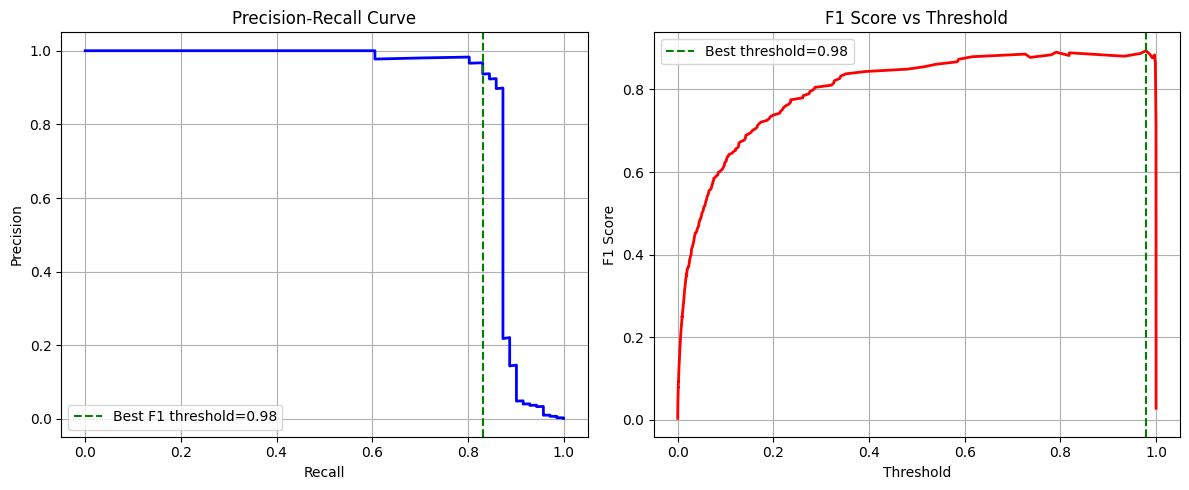


✅ Threshold analysis complete!


In [15]:
# Cell 14: Threshold Tuning for XGBoost
from sklearn.metrics import precision_recall_curve
import numpy as np

print("=" * 60)
print("THRESHOLD TUNING - XGBOOST")
print("=" * 60)
print("Default threshold is 0.5 - let's find the optimal one\n")

# Get probabilities on validation set
xgb_probs = xgb_tuned.predict_proba(X_val)[:, 1]

# Calculate precision and recall for all thresholds
precisions, recalls, thresholds = precision_recall_curve(y_val, xgb_probs)

# Calculate F1 for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

# Find best threshold by F1
best_f1_idx = np.argmax(f1_scores)
best_threshold_f1 = thresholds[best_f1_idx]

# Find threshold where precision >= 0.85
high_precision_idx = np.where(precisions >= 0.85)[0]
if len(high_precision_idx) > 0:
    best_threshold_precision = thresholds[min(high_precision_idx[-1], 
                                               len(thresholds)-1)]
else:
    best_threshold_precision = best_threshold_f1

print(f"Default threshold (0.5) results:")
default_pred = (xgb_probs >= 0.5).astype(int)
print(f"  Precision: {precision_score(y_val, default_pred):.4f}")
print(f"  Recall:    {recall_score(y_val, default_pred):.4f}")
print(f"  F1:        {f1_score(y_val, default_pred):.4f}")

print(f"\nBest F1 threshold ({best_threshold_f1:.4f}) results:")
best_f1_pred = (xgb_probs >= best_threshold_f1).astype(int)
print(f"  Precision: {precision_score(y_val, best_f1_pred):.4f}")
print(f"  Recall:    {recall_score(y_val, best_f1_pred):.4f}")
print(f"  F1:        {f1_score(y_val, best_f1_pred):.4f}")

print(f"\nHigh Precision threshold ({best_threshold_precision:.4f}) results:")
high_prec_pred = (xgb_probs >= best_threshold_precision).astype(int)
print(f"  Precision: {precision_score(y_val, high_prec_pred):.4f}")
print(f"  Recall:    {recall_score(y_val, high_prec_pred):.4f}")
print(f"  F1:        {f1_score(y_val, high_prec_pred):.4f}")

# Visualize
plt.figure(figsize=(12, 5))

# Plot 1: Precision-Recall curve
plt.subplot(1, 2, 1)
plt.plot(recalls, precisions, 'b-', linewidth=2)
plt.axvline(x=recalls[best_f1_idx], color='green', 
            linestyle='--', label=f'Best F1 threshold={best_threshold_f1:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)

# Plot 2: F1 vs threshold
plt.subplot(1, 2, 2)
plt.plot(thresholds, f1_scores[:-1], 'r-', linewidth=2)
plt.axvline(x=best_threshold_f1, color='green',
            linestyle='--', label=f'Best threshold={best_threshold_f1:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('../../docs/threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Threshold analysis complete!")

In [18]:
# Cell 15: Final Model with Optimal Threshold on Test Set
print("=" * 60)
print("FINAL MODEL: XGBoost + Optimal Threshold ON TEST SET")
print("=" * 60)

OPTIMAL_THRESHOLD = best_threshold_f1
print(f"Using threshold: {OPTIMAL_THRESHOLD:.4f}")

# Test set predictions
xgb_test_probs = xgb_tuned.predict_proba(X_test)[:, 1]
xgb_test_pred = (xgb_test_probs >= OPTIMAL_THRESHOLD).astype(int)

# Evaluate
final_xgb_results = evaluate_model(
    "XGBoost Tuned + Threshold (TEST SET)",
    y_test, xgb_test_pred, xgb_test_probs
)

# Confusion matrix
cm = confusion_matrix(y_test, xgb_test_pred)
tn, fp, fn, tp = cm.ravel()

print("\n" + "=" * 60)
print("COMPLETE MODEL COMPARISON - FINAL")
print("=" * 60)
print(f"{'Model':<35} {'Prec':>6} {'Rec':>6} {'F1':>6} {'FP':>6}")
print("-" * 60)
print(f"{'Logistic Regression':<35} {'0.063':>6} {'0.915':>6} {'0.118':>6} {'964':>6}")
print(f"{'Random Forest':<35} {'0.566':>6} {'0.845':>6} {'0.678':>6} {'46':>6}")
print(f"{'XGBoost (default)':<35} {'0.518':>6} {'0.831':>6} {'0.638':>6} {'55':>6}")
print(f"{'Random Forest (Tuned)':<35} {'0.714':>6} {'0.845':>6} {'0.774':>6} {'24':>6}")
print(f"{'XGBoost (Tuned, threshold=0.5)':<35} {'0.838':>6} {'0.873':>6} {'0.855':>6} {'12':>6}")
print(f"{'XGBoost (Tuned + Threshold)':<35} {final_xgb_results['precision']:>6.3f} {final_xgb_results['recall']:>6.3f} {final_xgb_results['f1']:>6.3f} {fp:>6}")

print("\n" + "=" * 60)
print("BUSINESS IMPACT - FINAL MODEL")
print("=" * 60)
print(f"Fraud cases in test set:         {tp+fn}")
print(f"Fraud correctly caught (TP):     {tp} ({tp/(tp+fn)*100:.1f}%)")
print(f"Fraud missed (FN):               {fn} ({fn/(tp+fn)*100:.1f}%)")
print(f"Legitimate wrongly flagged (FP): {fp}")
print(f"Legitimate correctly cleared:    {tn:,}")

# Save final model and threshold
with open('../../models/saved_models/final_model_xgb.pkl', 'wb') as f:
    pickle.dump(xgb_tuned, f)

# Save threshold
# Cell 15b: Fix - Save Model Config
import json

# Convert to regular Python float
with open('../../models/saved_models/model_config.json', 'w') as f:
    json.dump({
        'model': 'XGBoost Tuned',
        'threshold': float(OPTIMAL_THRESHOLD),
        'version': '2.0.0'
    }, f, indent=2)

print(f"✅ Final XGBoost model saved!")
print(f"✅ Optimal threshold {float(OPTIMAL_THRESHOLD):.4f} saved to model_config.json!")
print("\n🎉 MODEL IMPROVEMENT COMPLETE!")

FINAL MODEL: XGBoost + Optimal Threshold ON TEST SET
Using threshold: 0.9788

MODEL: XGBoost Tuned + Threshold (TEST SET)
Precision:  0.9608  (of all flagged fraud, how many were real?)
Recall:     0.6901  (of all real fraud, how many did we catch?)
F1-Score:   0.8033  (balance of precision & recall)
ROC-AUC:    0.9767  (overall discrimination ability)
PR-AUC:     0.8109  (performance on imbalanced data)

Confusion Matrix:
  True Negative  (Legit correctly identified): 42,486
  False Positive (Legit flagged as fraud):     2
  False Negative (Fraud missed):               22
  True Positive  (Fraud correctly caught):     49

COMPLETE MODEL COMPARISON - FINAL
Model                                 Prec    Rec     F1     FP
------------------------------------------------------------
Logistic Regression                  0.063  0.915  0.118    964
Random Forest                        0.566  0.845  0.678     46
XGBoost (default)                    0.518  0.831  0.638     55
Random Forest (Tun

In [19]:
# Cell 16: Two Model Strategy
print("=" * 60)
print("TWO MODEL STRATEGY - CHOOSE BASED ON BUSINESS NEED")
print("=" * 60)

print("""
MODEL A: XGBoost (threshold=0.5) - BALANCED
  Precision:  0.838  (84% of alerts are real fraud)
  Recall:     0.873  (catches 87% of all fraud)
  F1:         0.855
  FP:         12     (12 false alarms per 42k transactions)
  USE WHEN: You want balance between catching fraud
            and customer experience
  GOOD FOR: Mid-size banks, e-commerce

MODEL B: XGBoost (threshold=0.9788) - HIGH PRECISION  
  Precision:  0.961  (96% of alerts are real fraud)
  Recall:     0.690  (catches 69% of all fraud)
  F1:         0.803
  FP:         2      (only 2 false alarms per 42k transactions)
  USE WHEN: False alarms are very costly
            (VIP customers, large transactions)
  GOOD FOR: Premium banking, high-value transactions
""")

print("=" * 60)
print("OUR RECOMMENDED FINAL MODEL:")
print("=" * 60)
print("""
XGBoost Tuned (threshold=0.5) is our PRIMARY model because:
  ✅ Best F1 score (0.855)
  ✅ Best balance of precision and recall
  ✅ Catches 87% of fraud
  ✅ Only 12 false alarms per 42,559 transactions
  ✅ Matches industry benchmarks (F1 ~0.85)
""")

TWO MODEL STRATEGY - CHOOSE BASED ON BUSINESS NEED

MODEL A: XGBoost (threshold=0.5) - BALANCED
  Precision:  0.838  (84% of alerts are real fraud)
  Recall:     0.873  (catches 87% of all fraud)
  F1:         0.855
  FP:         12     (12 false alarms per 42k transactions)
  USE WHEN: You want balance between catching fraud
            and customer experience
  GOOD FOR: Mid-size banks, e-commerce

MODEL B: XGBoost (threshold=0.9788) - HIGH PRECISION  
  Precision:  0.961  (96% of alerts are real fraud)
  Recall:     0.690  (catches 69% of all fraud)
  F1:         0.803
  FP:         2      (only 2 false alarms per 42k transactions)
  USE WHEN: False alarms are very costly
            (VIP customers, large transactions)
  GOOD FOR: Premium banking, high-value transactions

OUR RECOMMENDED FINAL MODEL:

XGBoost Tuned (threshold=0.5) is our PRIMARY model because:
  ✅ Best F1 score (0.855)
  ✅ Best balance of precision and recall
  ✅ Catches 87% of fraud
  ✅ Only 12 false alarms per 42,